In [1]:
# --- Configuración de entorno ---

# Añade el directorio raíz al path para que Python encuentre tus módulos
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))  # Sube dos niveles hasta /src

# Importa configuraciones y librerías globales
from config import *
from utils import *

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

# Carga de los ficheros de dimensiones parciales

Se carga los ficheros con los datos que se emplearan en cada dimensión

In [2]:
def load(path):
    df = pd.read_csv(path, encoding="utf-8", sep = ';', decimal = ',')
    return df

DA_seccion = load(os.path.join(DATA_OUTPUTS_DA, "DA_Seccion.csv"))
DH_seccion = load(os.path.join(DATA_OUTPUTS_DH, "DH_Seccion.csv"))
DS_seccion = load(os.path.join(DATA_OUTPUTS_DS, "DS_Seccion.csv"))
DD_seccion = load(os.path.join(DATA_OUTPUTS_DD, "DD_Seccion.csv"))

datasets = [DA_seccion, DH_seccion, DS_seccion, DD_seccion]

for df in datasets:
    df["CUSEC"] = df["CUSEC"].astype(str).str.zfill(10)
    
def print_columns(title, df):
    print("\n" + "-" * 70)
    print(title)
    print("-" * 70)

    cols = df.columns.tolist()

    for i, col in enumerate(cols, start=1):
        print(f"{i:3d}. {col}")

    print("-" * 70)
    print(f"Total columnas: {len(cols)}")
    print("-" * 70 + "\n")


print_columns("DIMENSIÓN ACCESO A SERVICIOS (DA)", DA_seccion)
print_columns("DIMENSIÓN HABITACIONAL (DH)", DH_seccion)
print_columns("DIMENSIÓN SOCIOECONÓMICA (DS)", DS_seccion)
print_columns("DIMENSIÓN DEMOGRÁFICA (DD)", DD_seccion)


----------------------------------------------------------------------
DIMENSIÓN ACCESO A SERVICIOS (DA)
----------------------------------------------------------------------
  1. CUSEC
  2. dist_min_ceas_km
  3. n_ceas_1km
  4. n_ceas_5km
  5. n_ceas_15km
  6. n_ceas_30km
  7. disp_ponderada_ceas
  8. dist_min_especializada_km
  9. n_especializada_1km
 10. n_especializada_5km
 11. n_especializada_15km
 12. n_especializada_30km
 13. disp_ponderada_especializada
 14. dist_min_primaria_km
 15. n_primaria_1km
 16. n_primaria_5km
 17. n_primaria_15km
 18. n_primaria_30km
 19. disp_ponderada_primaria
 20. dist_min_infantil_y_primaria_km
 21. n_infantil_y_primaria_1km
 22. n_infantil_y_primaria_5km
 23. n_infantil_y_primaria_15km
 24. n_infantil_y_primaria_30km
 25. disp_ponderada_infantil_y_primaria
 26. dist_min_adultos_e_idiomas_km
 27. n_adultos_e_idiomas_1km
 28. n_adultos_e_idiomas_5km
 29. n_adultos_e_idiomas_15km
 30. n_adultos_e_idiomas_30km
 31. disp_ponderada_adultos_e_idiomas
 

# Incorporación de variables resumen
Como tengo muchas variables, voy a condensar algunas en una tasa de paro, tasa de actividad, dependencia de prestaciones, vulnerabilidad educativa

In [3]:
DS_seccion["poblacion_total"] = (
    DS_seccion["Total_Ocupado"] +
    DS_seccion["Total_Parado"] +
    DS_seccion["Total_Estudiante"] +
    DS_seccion["Total_Otra_inactividad"] +
    DS_seccion["Total_Pensiones"]
)

DS_seccion["activos"] = DS_seccion["Total_Ocupado"] + DS_seccion["Total_Parado"]
DS_seccion["tasa_actividad"] = DS_seccion["activos"] / DS_seccion["poblacion_total"]
DS_seccion["tasa_paro"] = DS_seccion["Total_Parado"] / DS_seccion["activos"]

# Elijo otras prestaciones y desempleo como indicadores de más vulnerabilidad (inestabilidad) que las pensiones, salarios u otros ingresos
# Redimensiono las prestaciones mínimas porque implican más vulnerabilidad que el desempleo.
DS_seccion["dep_asistencial"] = (
    0.5 * DS_seccion["Fuente_de_ingreso_prestaciones_por_desempleo"] +
    1 * DS_seccion["Fuente_de_ingreso_otras_prestaciones"]
)

# Con el nivel de estudios algo similar
DS_seccion["edu_total"] = (
    DS_seccion["Total_Educación_primaria_e_inferior"] +
    DS_seccion["Total_Primera_etapa_de_Educación_Secundaria_y_similar"] +
    DS_seccion["Total_Segunda_etapa_de_Educación_Secundaria_y_Educación_Postsecundaria_no_Superior"] +
    DS_seccion["Total_Educación_superior"]
)
DS_seccion["pct_edu_primaria"] = DS_seccion["Total_Educación_primaria_e_inferior"] / DS_seccion["edu_total"]
DS_seccion["pct_edu_secundaria_baja"] = DS_seccion["Total_Primera_etapa_de_Educación_Secundaria_y_similar"] / DS_seccion["edu_total"]
DS_seccion["pct_edu_secundaria_alta"] = DS_seccion["Total_Segunda_etapa_de_Educación_Secundaria_y_Educación_Postsecundaria_no_Superior"] / DS_seccion["edu_total"]
DS_seccion["pct_edu_superior"] = DS_seccion["Total_Educación_superior"] / DS_seccion["edu_total"]
DS_seccion["indice_educativo"] = (
    0.00 * DS_seccion["pct_edu_primaria"] +
    0.33 * DS_seccion["pct_edu_secundaria_baja"] +
    0.66 * DS_seccion["pct_edu_secundaria_alta"] +
    1.00 * DS_seccion["pct_edu_superior"]
)
DS_seccion["vul_edu"]= 1 - DS_seccion["indice_educativo"]
DS_seccion.sample(5)

,Provincia,CMuni,CUSEC,Periodo,Hombres_Estudiante,Hombres_Ocupado_a,Hombres_Otra_situación_de_inactividad,Hombres_Parado_a,"Hombres_Perceptor_a_pensión_de_incapacidad,_jubilación,_prejubilación",Mujeres_Estudiante,Mujeres_Ocupado_a,Mujeres_Otra_situación_de_inactividad,Mujeres_Parado_a,"Mujeres_Perceptor_a_pensión_de_incapacidad,_jubilación,_prejubilación",Total_Estudiante,Total_Ocupado,Total_Otra_inactividad,Total_Parado,Total_Pensiones,Hombres_Educación_primaria_e_inferior,Hombres_Educación_superior,Hombres_Primera_etapa_de_Educación_Secundaria_y_similar,Hombres_Segunda_etapa_de_Educación_Secundaria_y_Educación_Postsecundaria_no_Superior,Mujeres_Educación_primaria_e_inferior,Mujeres_Educación_superior,Mujeres_Primera_etapa_de_Educación_Secundaria_y_similar,Mujeres_Segunda_etapa_de_Educación_Secundaria_y_Educación_Postsecundaria_no_Superior,Total_Educación_primaria_e_inferior,Total_Educación_superior,Total_Primera_etapa_de_Educación_Secundaria_y_similar,Total_Segunda_etapa_de_Educación_Secundaria_y_Educación_Postsecundaria_no_Superior,Fuente_de_ingreso_otras_prestaciones,Fuente_de_ingreso_otros_ingresos,Fuente_de_ingreso_pensiones,Fuente_de_ingreso_prestaciones_por_desempleo,Fuente_de_ingreso_salario,Distribución_de_la_renta_P80_P20,Índice_de_Gini,Media_de_la_renta_por_unidad_de_consumo,Mediana_de_la_renta_por_unidad_de_consumo,Renta_bruta_media_por_hogar,Renta_bruta_media_por_persona,Renta_neta_media_por_hogar,Renta_neta_media_por_persona,Seccion_id,poblacion_total,activos,tasa_actividad,tasa_paro,dep_asistencial,edu_total,pct_edu_primaria,pct_edu_secundaria_baja,pct_edu_secundaria_alta,pct_edu_superior,indice_educativo,vul_edu
4930,Salamanca,37306,3730601001,2022,3,49,13,7,56,3,28,48,5,20,6,77,61,12,76,24,21,58,26,40,23,30,12,64,44,88,38,5.5,16.7,35.1,1.5,41.3,2.7,33.0,16090,13650,23395,14879,20329,12929,2014.0,232,89,0.383621,0.134831,6.25,234,0.273504,0.376068,0.162393,0.188034,0.419316,0.580684
6332,Valladolid,47085,4708501006,2023,48,224,33,21,150,41,209,140,25,70,89,433,173,46,220,72,105,200,104,104,151,135,99,176,256,335,203,3.6,9.6,25.9,1.2,59.8,2.5,26.8,21040,19950,42635,17078,35550,14240,2719.0,961,479,0.498439,0.096033,4.20,970,0.181443,0.345361,0.209278,0.263918,0.516010,0.483990
5631,Segovia,40194,4019407003,2023,59,380,100,37,171,53,370,224,53,134,112,750,324,90,305,139,167,275,178,204,247,233,164,343,414,508,342,4.7,8.4,24.1,1.8,61.1,2.4,29.6,19086,16450,38126,15635,32268,13233,2330.0,1581,840,0.531309,0.107143,5.60,1607,0.213441,0.316117,0.212819,0.257623,0.502402,0.497598
4979,Salamanca,37330,3733001001,2022,5,83,9,6,57,5,53,64,13,15,10,136,73,19,72,19,23,91,30,33,40,56,21,52,63,147,51,4.9,15.2,26.7,1.8,51.4,2.3,28.9,19809,17150,36091,16206,30711,13791,2037.0,310,155,0.500000,0.122581,5.80,313,0.166134,0.469649,0.162939,0.201278,0.463802,0.536198
7153,Valladolid,47186,4718610006,2022,32,263,30,34,141,40,230,150,50,109,72,493,180,84,250,78,136,160,128,125,168,162,133,203,304,322,261,4.1,7.7,25.8,1.9,60.6,2.4,27.3,19883,18550,38025,16668,31707,13898,3520.0,1079,577,0.534754,0.145581,5.05,1090,0.186239,0.295413,0.239450,0.278899,0.534422,0.465578


# Incorporación de población para hacinamiento y disponibilidad relativa de cobertura sanitaria
Las dimensiones Habitacional y de Servicios se suponen constantes a lo largo de los 3 años. Sin embargo, es posible conferir cierto dinamismo incorporando a la dimension habitacional un hacinamiento (como la superficie / tamaño medio del hogar por año) y a la dimensión de servicios una disponibilidad ponderada por distancia y población (de esta forma se evita el sesgo de que la disponibilidad en ciudades sea significativamnente mayor que en areas rurales)

In [4]:
# ----------------------------
# HACINAMIENTO (DH + DD)
# ----------------------------

# Crear tabla base única de DH
DH_base = DH_seccion[["CUSEC", "numero_bienes", "superficie_media",
                      "antiguedad_media", "dispersion_antiguedad",
                      "pct_reformado_2000", "dispersion_superficie"]].drop_duplicates()

# Añadir tamaño del hogar por año (desde DD)
hacinamiento_list = []

for year in [2021, 2022, 2023]:
    dd_year = DD_seccion[DD_seccion["Periodo"] == year][[
        "CUSEC", "Tamaño_medio_del_hogar"
    ]]

    merged = DH_base.merge(dd_year, on="CUSEC", how="left").copy()
    merged["Periodo"] = year
    merged["hacinamiento"] =   merged["Tamaño_medio_del_hogar"] / merged["superficie_media"]

    # Nos quedamos con columnas clave
    hacinamiento_list.append(
        merged[[
            "CUSEC", "Periodo", "hacinamiento", "superficie_media",
            "numero_bienes", "antiguedad_media", "dispersion_antiguedad",
            "pct_reformado_2000", "dispersion_superficie"
        ]]
    )

# Concatenar todo en formato largo
DH_seccion = pd.concat(hacinamiento_list, ignore_index=True)

In [5]:
DH_seccion.head()

,CUSEC,Periodo,hacinamiento,superficie_media,numero_bienes,antiguedad_media,dispersion_antiguedad,pct_reformado_2000,dispersion_superficie
0,0500101001,2021,0.009016,232.915,260,1958.0,0.02,3.11,0.64
1,0500201001,2021,0.014798,148.670,2308,1987.0,0.01,0.58,0.55
2,0500201002,2021,0.015965,137.800,2234,1985.0,0.01,0.43,0.59
3,0500501001,2021,0.007164,251.241,158,1974.0,0.02,11.89,0.66
4,0500701001,2021,0.011499,191.321,159,1976.0,0.02,19.12,0.51


In [6]:
# ----------------------------
# 2. DISPONIBILIDAD SANITARIA POR HABITANTE
# ----------------------------
disp_sanitario = (
      0.8 * DA_seccion["disp_ponderada_primaria"]
    + 0.2 * DA_seccion["disp_ponderada_especializada"]
)

for year in [2021, 2022, 2023]:
    dd_year = DD_seccion[DD_seccion["Periodo"] == year][["CUSEC", "Población"]]
    
    merged = DA_seccion[["CUSEC"]].copy()
    merged["disp_sanitaria"] = disp_sanitario

    merged = merged.merge(dd_year, on="CUSEC", how="left")

    DA_seccion[f"disp_sanitaria_por_hab_{year}"] = (
        merged["disp_sanitaria"] / merged["Población"]
    )

# Ahora creamos el long format
DA_list = []

for year in [2021, 2022, 2023]:
    tmp = DA_seccion.copy()
    tmp["Periodo"] = year
    tmp["disp_sanitaria_por_hab"] = tmp[f"disp_sanitaria_por_hab_{year}"]
    DA_list.append(tmp)

DA_long = pd.concat(DA_list, ignore_index=True)

# Orden correcto
DA_seccion = DA_long.sort_values(["CUSEC", "Periodo"]).reset_index(drop=True)

DA_seccion.head()


,CUSEC,dist_min_ceas_km,n_ceas_1km,n_ceas_5km,n_ceas_15km,n_ceas_30km,disp_ponderada_ceas,dist_min_especializada_km,n_especializada_1km,n_especializada_5km,n_especializada_15km,n_especializada_30km,disp_ponderada_especializada,dist_min_primaria_km,n_primaria_1km,n_primaria_5km,n_primaria_15km,n_primaria_30km,disp_ponderada_primaria,dist_min_infantil_y_primaria_km,n_infantil_y_primaria_1km,n_infantil_y_primaria_5km,n_infantil_y_primaria_15km,n_infantil_y_primaria_30km,disp_ponderada_infantil_y_primaria,dist_min_adultos_e_idiomas_km,n_adultos_e_idiomas_1km,n_adultos_e_idiomas_5km,n_adultos_e_idiomas_15km,n_adultos_e_idiomas_30km,disp_ponderada_adultos_e_idiomas,dist_min_secundaria_y_bachillerato_km,n_secundaria_y_bachillerato_1km,n_secundaria_y_bachillerato_5km,n_secundaria_y_bachillerato_15km,n_secundaria_y_bachillerato_30km,disp_ponderada_secundaria_y_bachillerato,dist_min_educación_especial_km,n_educación_especial_1km,n_educación_especial_5km,n_educación_especial_15km,n_educación_especial_30km,disp_ponderada_educación_especial,dist_min_formación_profesional_km,n_formación_profesional_1km,n_formación_profesional_5km,n_formación_profesional_15km,n_formación_profesional_30km,disp_ponderada_formación_profesional,dist_min_inclusión_social_km,n_inclusión_social_1km,n_inclusión_social_5km,n_inclusión_social_15km,n_inclusión_social_30km,disp_ponderada_inclusión_social,dist_min_población_general_km,n_población_general_1km,n_población_general_5km,n_población_general_15km,n_población_general_30km,disp_ponderada_población_general,dist_min_toxicomanías_y_adicciones_km,n_toxicomanías_y_adicciones_1km,n_toxicomanías_y_adicciones_5km,n_toxicomanías_y_adicciones_15km,n_toxicomanías_y_adicciones_30km,disp_ponderada_toxicomanías_y_adicciones,dist_min_personas_con_discapacidad_km,n_personas_con_discapacidad_1km,n_personas_con_discapacidad_5km,n_personas_con_discapacidad_15km,n_personas_con_discapacidad_30km,disp_ponderada_personas_con_discapacidad,dist_min_familia_km,n_familia_1km,n_familia_5km,n_familia_15km,n_familia_30km,disp_ponderada_familia,dist_min_mujer_km,n_mujer_1km,n_mujer_5km,n_mujer_15km,n_mujer_30km,disp_ponderada_mujer,dist_min_infancia_y_juventud_km,n_infancia_y_juventud_1km,n_infancia_y_juventud_5km,n_infancia_y_juventud_15km,n_infancia_y_juventud_30km,disp_ponderada_infancia_y_juventud,dist_min_voluntariado_km,n_voluntariado_1km,n_voluntariado_5km,n_voluntariado_15km,n_voluntariado_30km,disp_ponderada_voluntariado,dist_min_personas_mayores_km,n_personas_mayores_1km,n_personas_mayores_5km,n_personas_mayores_15km,n_personas_mayores_30km,disp_ponderada_personas_mayores,Seccion_id,disp_sanitaria_por_hab_2021,disp_sanitaria_por_hab_2022,disp_sanitaria_por_hab_2023,Periodo,disp_sanitaria_por_hab
0,0500101001,5.689,0,0,1,3,0.5,27.566,0,0,0,1,0.1,12.416,0,0,2,10,1.4,5.689,0,0,4,16,2.4,15.854,0,0,0,3,0.3,12.416,0,0,1,6,0.8,34.061,0,0,0,0,0.0,27.948,0,0,0,1,0.1,26.457,0,0,0,1,0.1,30.427,0,0,0,0,0.0,30.427,0,0,0,0,0.0,31.279,0,0,0,0,0.0,31.279,0,0,0,0,0.0,9.429,0,0,1,1,0.3,30.427,0,0,0,0,0.0,31.279,0,0,0,0,0.0,16.638,0,0,0,2,0.2,1,0.005816,0.005278,0.005403,2021,0.005816
1,0500101001,5.689,0,0,1,3,0.5,27.566,0,0,0,1,0.1,12.416,0,0,2,10,1.4,5.689,0,0,4,16,2.4,15.854,0,0,0,3,0.3,12.416,0,0,1,6,0.8,34.061,0,0,0,0,0.0,27.948,0,0,0,1,0.1,26.457,0,0,0,1,0.1,30.427,0,0,0,0,0.0,30.427,0,0,0,0,0.0,31.279,0,0,0,0,0.0,31.279,0,0,0,0,0.0,9.429,0,0,1,1,0.3,30.427,0,0,0,0,0.0,31.279,0,0,0,0,0.0,16.638,0,0,0,2,0.2,1,0.005816,0.005278,0.005403,2022,0.005278
2,0500101001,5.689,0,0,1,3,0.5,27.566,0,0,0,1,0.1,12.416,0,0,2,10,1.4,5.689,0,0,4,16,2.4,15.854,0,0,0,3,0.3,12.416,0,0,1,6,0.8,34.061,0,0,0,0,0.0,27.948,0,0,0,1,0.1,26.457,0,0,0,1,0.1,30.427,0,0,0,0,0.0,30.427,0,0,0,0,0.0,31.279,0,0,0,0,0.0,31.279,0,0,0,0,0.0,9.429,0,0,1,1,0.3,30.427,0,0,0,0,0.0,31.279,0,0,0,0,0.0,16.638,0,0,0,2,0.2,1,0.005816,0.005278,0.005403,2023,0.005403
3,0500201001,6.278,0,0,3,6,1.2,36.403,0,0,0,0,0.0,6.210,0,0,2,9,1.3,0.000,2,2,11,24,6.0,6.278,0,0,1,2,0.4,0.000,1,1,3,5,1.8,40.3

In [7]:
# Incluyo un indicador generíco como disponibilidad ponderada servicios sociales

In [8]:
DA_seccion["disp_ponderada_servicios_sociales"] = (
      DA_seccion["disp_ponderada_personas_con_discapacidad"]
    + DA_seccion["disp_ponderada_mujer"]
    + DA_seccion["disp_ponderada_inclusión_social"]
    + DA_seccion["disp_ponderada_personas_mayores"]
) / 4

In [9]:

# Elimino columnas
DA_seccion = DA_seccion.drop(columns=["disp_sanitaria_por_hab_2021", "disp_sanitaria_por_hab_2022", "disp_sanitaria_por_hab_2023"])
DA_seccion.sample(5)


,CUSEC,dist_min_ceas_km,n_ceas_1km,n_ceas_5km,n_ceas_15km,n_ceas_30km,disp_ponderada_ceas,dist_min_especializada_km,n_especializada_1km,n_especializada_5km,n_especializada_15km,n_especializada_30km,disp_ponderada_especializada,dist_min_primaria_km,n_primaria_1km,n_primaria_5km,n_primaria_15km,n_primaria_30km,disp_ponderada_primaria,dist_min_infantil_y_primaria_km,n_infantil_y_primaria_1km,n_infantil_y_primaria_5km,n_infantil_y_primaria_15km,n_infantil_y_primaria_30km,disp_ponderada_infantil_y_primaria,dist_min_adultos_e_idiomas_km,n_adultos_e_idiomas_1km,n_adultos_e_idiomas_5km,n_adultos_e_idiomas_15km,n_adultos_e_idiomas_30km,disp_ponderada_adultos_e_idiomas,dist_min_secundaria_y_bachillerato_km,n_secundaria_y_bachillerato_1km,n_secundaria_y_bachillerato_5km,n_secundaria_y_bachillerato_15km,n_secundaria_y_bachillerato_30km,disp_ponderada_secundaria_y_bachillerato,dist_min_educación_especial_km,n_educación_especial_1km,n_educación_especial_5km,n_educación_especial_15km,n_educación_especial_30km,disp_ponderada_educación_especial,dist_min_formación_profesional_km,n_formación_profesional_1km,n_formación_profesional_5km,n_formación_profesional_15km,n_formación_profesional_30km,disp_ponderada_formación_profesional,dist_min_inclusión_social_km,n_inclusión_social_1km,n_inclusión_social_5km,n_inclusión_social_15km,n_inclusión_social_30km,disp_ponderada_inclusión_social,dist_min_población_general_km,n_población_general_1km,n_población_general_5km,n_población_general_15km,n_población_general_30km,disp_ponderada_población_general,dist_min_toxicomanías_y_adicciones_km,n_toxicomanías_y_adicciones_1km,n_toxicomanías_y_adicciones_5km,n_toxicomanías_y_adicciones_15km,n_toxicomanías_y_adicciones_30km,disp_ponderada_toxicomanías_y_adicciones,dist_min_personas_con_discapacidad_km,n_personas_con_discapacidad_1km,n_personas_con_discapacidad_5km,n_personas_con_discapacidad_15km,n_personas_con_discapacidad_30km,disp_ponderada_personas_con_discapacidad,dist_min_familia_km,n_familia_1km,n_familia_5km,n_familia_15km,n_familia_30km,disp_ponderada_familia,dist_min_mujer_km,n_mujer_1km,n_mujer_5km,n_mujer_15km,n_mujer_30km,disp_ponderada_mujer,dist_min_infancia_y_juventud_km,n_infancia_y_juventud_1km,n_infancia_y_juventud_5km,n_infancia_y_juventud_15km,n_infancia_y_juventud_30km,disp_ponderada_infancia_y_juventud,dist_min_voluntariado_km,n_voluntariado_1km,n_voluntariado_5km,n_voluntariado_15km,n_voluntariado_30km,disp_ponderada_voluntariado,dist_min_personas_mayores_km,n_personas_mayores_1km,n_personas_mayores_5km,n_personas_mayores_15km,n_personas_mayores_30km,disp_ponderada_personas_mayores,Seccion_id,Periodo,disp_sanitaria_por_hab,disp_ponderada_servicios_sociales
5632,3724201001,14.618,0,0,1,3,0.5,34.591,0,0,0,0,0.0,13.462,0,0,2,6,1.0,4.890,0,1,5,23,3.6,16.404,0,0,0,1,0.1,16.272,0,0,0,4,0.4,32.153,0,0,0,0,0.0,33.697,0,0,0,0,0.0,16.272,0,0,0,3,0.3,34.072,0,0,0,0,0.0,30.806,0,0,0,0,0.0,33.878,0,0,0,0,0.0,34.072,0,0,0,0,0.0,32.511,0,0,0,0,0.0,32.511,0,0,0,0,0.0,33.878,0,0,0,0,0.0,18.720,0,0,0,1,0.1,1822,2022,0.010526,0.100
10361,4923901001,15.858,0,0,0,3,0.3,31.544,0,0,0,0,0.0,16.255,0,0,0,8,0.8,4.943,0,1,4,21,3.2,16.255,0,0,0,1,0.1,8.133,0,0,1,5,0.7,32.324,0,0,0,0,0.0,32.037,0,0,0,0,0.0,8.133,0,0,2,3,0.7,26.693,0,0,0,2,0.2,30.551,0,0,0,0,0.0,26.693,0,0,0,5,0.5,32.002,0,0,0,0,0.0,8.133,0,0,1,3,0.5,30.551,0,0,0,0,0.0,32.002,0,0,0,0,0.0,24.494,0,0,0,2,0.2,3389,2023,0.001060,0.475
5684,3725601001,15.348,0,0,0,3,0.3,35.519,0,0,0,0,0.0,9.776,0,0,4,14,2.2,7.023,0,0,5,26,3.6,18.014,0,0,0,1,0.1,15.348,0,0,0,6,0.6,35.430,0,0,0,0,0.0,32.151,0,0,0,0,0.0,33.035,0,0,0,0,0.0,33.700,0,0,0,0,0.0,33.700,0,0,0,0,0.0,33.762,0,0,0,0,0.0,33.035,0,0,0,0,0.0,33.035,0,0,0,0,0.0,33.035,0,0,0,0,0.0,33.700,0,0,0,0,0.0,6.063,0,0,1,4,0.6,1839,2023,0.008800,0.150
6960,4016801001,31.780,0,0,0,0,0.0,31.775,0,0,0,0,0.0,13.645,0,0,2,9,1.3,13.645,0,0,3,13,1.9,7.041,0,0,1,2,0.4,13.645,0,0,1,3,0.5,32.440,0,0,0,0,0.0,31.643,0,0,0,0,0.0,8.240,0,0,3,4,1.0,31.658,0,0,0,0,0.0,29.075,0,0,0,1,0.1

# Selección de variables DA
Ahora mismo hay demasiadas variables dentro de la DA, por lo que para que el PCA sea adecuado hago una selección previa de las variables que más pueden representar el conjunto de los datos de acuerdo a la literatura.

| Variable                                       | Descripción                                                                                                         | Motivo de selección                                                                                                  |
|------------------------------------------------|---------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------|
| **Seccion_id**                                 | Identificador único de la sección censal.                                                                           | Necesario para fusiones, uniones y ordenación temporal.                                                               |
| **Periodo**                                    | Año de referencia del indicador (2021-2023).                                                                        | Permite análisis longitudinal y construcción de índices comparables.                                                  |
| **disp_sanitario_por_hab**                     | Disponibilidad sanitaria ponderada (primaria 80%, especializada 20%) dividida entre la población.                   | Combina acceso físico y presión demográfica; evita penalizar áreas rurales con baja población.                        |
| **disp_ponderada_servicios_sociales**          | Media ponderada de la disponibilidad en discapacidad, mujer, inclusión y mayores.                                   | Resume en un único índice los servicios sociales esenciales de referencia.                                            |
| **dist_min_ceas_km**                           | Distancia mínima al CEAS.                                                                                           | CEAS = puerta de entrada del Sistema de Servicios Sociales; variable obligatoria.                                     |
| **dist_min_primaria_km**                       | Distancia mínima a un centro de salud de atención primaria.                                                         | Indicador básico de accesibilidad sanitaria general.                                                                  |
| **dist_min_especializada_km**                  | Distancia mínima a un centro de atención especializada.                                                             | Refleja desigualdad territorial en servicios hospitalarios y complejos.                                               |
| **disp_ponderada_secundaria_y_bachillerato**   | Disponibilidad ponderada de centros de ESO + Bachillerato.                                                          | Relevante para jóvenes; la ponderación incluye transporte y comedor, mejor que la distancia.                          |
| **disp_ponderada_infantil_y_primaria**         | Disponibilidad ponderada de centros de infantil + primaria.                                                         | Fundamental para familias; la ponderación representa accesibilidad real.                                              |
| **dist_min_formación_profesional_km**          | Distancia mínima a un centro de FP.                                                                                 | Clave para empleabilidad y desarrollo de capital humano.                                                              |
| **dist_min_educación_especial_km**              | Distancia mínima a un centro de educación especial.                                                                  | Servicio escaso territorialmente; indicador crítico para familias con necesidad de apoyos específicos.                |


# Selección de variables DH
En este caso me quedo con todas las variables puesto que tengo pocas

# Selección de variables DS

La siguiente selección recoge las variables socioeconómicas esenciales para la construcción del índice DS. Se han elegido únicamente indicadores no redundantes, con base empírica y apoyados en la literatura sobre vulnerabilidad económica, exclusión y desigualdad.

| Variable                                      | Descripción                                                                                                    | Motivo de selección                                                                                                   |
|-----------------------------------------------|----------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------|
| **Seccion_id**                                | Identificador único de la sección censal.                                                                      | Necesario para fusiones, ordenación y análisis longitudinal. No entra en el PCA.                                       |
| **Periodo**                                   | Año de referencia (2021–2023).                                                                                | Permite estudios longitudinales y comparabilidad temporal. No entra en el PCA.                                         |
| **Renta_neta_media_por_hogar**                | Renta neta media anual por hogar.                                                                             | Indicador central del bienestar económico; discrimina fuertemente entre territorios. Se invierte.                     |
| **Renta_neta_media_por_persona**              | Renta neta media anual por persona.                                                                           | Complementa la versión por hogar; más estable ante variaciones del tamaño familiar. Se invierte.                      |
| **tasa_paro**                                 | Proporción de población activa que se encuentra desempleada.                                                  | Indicador clásico de precariedad laboral y riesgo económico inmediato.                                                |
| **tasa_actividad**                            | Proporción de población activa respecto a la población total de 16+.                                          | Mide dinamismo económico y participación laboral; menor actividad implica mayor vulnerabilidad. Se invierte.          |
| **dep_asistencial**                           | Índice ponderado: 0.5 × prestaciones por desempleo + 1 × otras prestaciones.                               | Captura dependencia económica asistencial; indicador sólido de vulnerabilidad.                                        |
| **vul_edu**                                   | Índice sintético de bajo nivel educativo (invertido: mayor valor = peor situación).                           | Condensa la estructura educativa sin multicolinealidad; predictor clave de exclusión social.                          |
| **Distribución_de_la_renta_P80_P20**          | Ratio entre percentil 80 y percentil 20 de la renta.                                                           | Representa desigualdad interna y brecha entre rentas altas y bajas.                                                   |
| **Índice_de_Gini**                             | Índice de desigualdad (0–1).                                                                                  | Mide concentración de la renta; aporta una dimensión diferenciada respecto a renta y empleo.                           |


# Selección de variables DD

La dimensión demográfica sintetiza la estructura poblacional de cada sección censal mediante indicadores de envejecimiento, dependencia, estructura de hogar y ruralidad. Se excluyen los conteos absolutos y los rangos de edad individuales debido a su colinealidad y escasa aportación al PCA.

| Variable                                | Descripción                                                                                         | Motivo de selección                                                                                                     |
|-----------------------------------------|-----------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------|
| **Seccion_id**                          | Identificador único de la sección censal.                                                           | Necesario para fusiones y vinculación con el resto del IVST. No se usa en el PCA.                                       |
| **Periodo**                             | Año de referencia (2021–2023).                                                                      | Permite análisis longitudinal. No entra en PCA.                                                                          |
| **Edad_media_de_la_población**          | Media de edad de la población residente.                                                            | Resumen robusto del envejecimiento general; evita colinealidad de los rangos de edad.                                   |
| **Porcentaje_de_hogares_unipersonales** | Proporción de hogares formados por una sola persona.                                                | Asociado a aislamiento, envejecimiento y vulnerabilidad social, especialmente relevante en áreas rurales.               |
| **Tasa_Dependencia**                    | (Población <16 + >65) / población 16–64.                                                            | Indicador estándar de carga demográfica y sostenibilidad.                                                                |
| **Indice_Envejecimiento**               | Población mayor de 65 / población menor de 16.                                                      | Captura el balance generacional y la capacidad de reemplazo poblacional.                                                 |
| **Porcentaje_de_población_extranjera**  | Proporción de población extranjera residente.                                                       | Indicador de diversidad, movilidad y atracción/dinamismo demográfico.                                                    |
| **Tamaño_medio_del_hogar**              | Número medio de personas por hogar.                                                                 | Relacionado con composición demográfica y estructura familiar; se invierte (hogares pequeños → mayor vulnerabilidad).   |
| **Densidad de población**               | Habitantes por km².                                                                                 | Diferencia áreas urbanas y rurales; baja densidad implica mayor riesgo de despoblamiento. Se invierte.                 |


# Funciones auxiliares PCA

In [10]:
# APLICANDO PCA
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

def invertir_variables(df, vars_invertir):
    df = df.copy()
    for var in vars_invertir:
        df[var] = df[var].max() - df[var]
    return df



def imputar_escalar(df, vars_pca):
    imputer = KNNImputer(n_neighbors=5)
    X_imputed = imputer.fit_transform(df[vars_pca])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    return X_scaled


def pca_dimension(df, vars_pca, nombre_indice, var_referencia=None):

    X_scaled = imputar_escalar(df, vars_pca)

    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # PC1
    pc1 = X_pca[:, 0].copy()

    # Loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=vars_pca,
        columns=[f"PC{i+1}" for i in range(len(vars_pca))]
    )

    # ====== 2. NORMALIZACIÓN DESPUÉS DEL FLIP ======
    pc1_norm = (pc1 - pc1.min()) / (pc1.max() - pc1.min()) * 100

    # ====== 3. SALIDA ======
    df_out = df[["CUSEC", "Periodo"]].copy()
    df_out[nombre_indice] = pc1_norm

    return pca, df_out, pca.explained_variance_ratio_, loadings

def plot_corr(df, vars_dim, titulo, figsize=(12, 9)):
    """
    df: dataframe completo (incluye CUSEC, Periodo)
    vars_dim: lista de variables numéricas de la dimensión
    titulo: título del gráfico
    """

    corr = df[vars_dim].corr()

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        cmap='coolwarm',
        center=0,
        annot=True,      # True si quieres ver los coeficientes
        fmt=".2f"
    )
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

    return corr

def plot_scree(pca, titulo="Scree plot – PCA"):
    plt.figure(figsize=(10, 6))
    pcs = np.arange(1, len(pca.explained_variance_ratio_) + 1)
    plt.plot(pcs, pca.explained_variance_ratio_, marker='o')
    plt.title(titulo)
    plt.xlabel("Componentes principales")
    plt.ylabel("Varianza explicada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_loadings_positive(loadings, pc="PC1", titulo="Pesos de PC1"):
    plt.figure(figsize=(10, 6))
    loadings_pc = loadings[pc]

    # Convertimos todos los pesos a valor absoluto
    loadings_pc_abs = loadings_pc.abs().sort_values()

    loadings_pc_abs.plot(kind='barh', color='steelblue')
    plt.title(titulo + " (valor absoluto)")
    plt.xlabel("Peso (absoluto)")
    plt.tight_layout()
    plt.show()

# APLICACIÓN DE PCA A DIMENSIÓN SERVICIOS (DA)

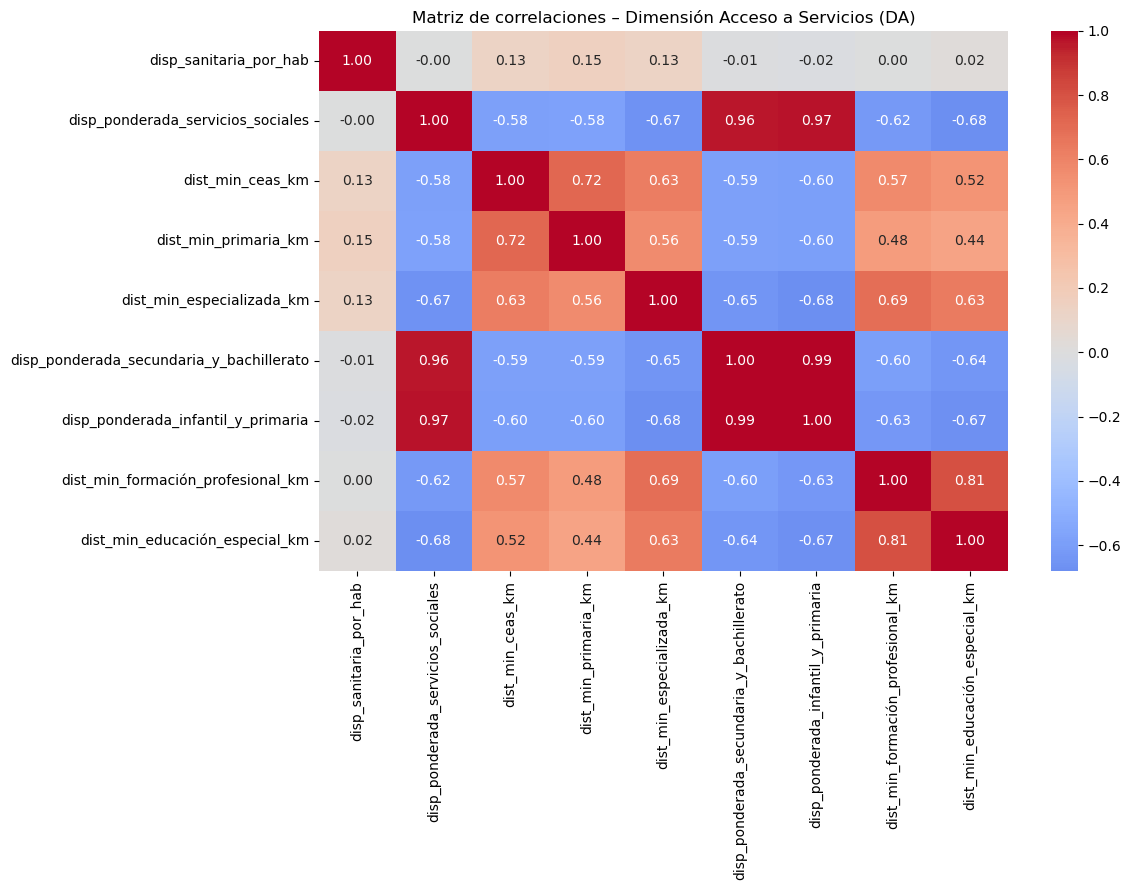

In [33]:
# ==========================
# 1. Selección variables DA
# ==========================
vars_da = [
    "disp_sanitaria_por_hab",
    "disp_ponderada_servicios_sociales",
    "dist_min_ceas_km",
    "dist_min_primaria_km",
    "dist_min_especializada_km",
    "disp_ponderada_secundaria_y_bachillerato",
    "disp_ponderada_infantil_y_primaria",
    "dist_min_formación_profesional_km",
    "dist_min_educación_especial_km"
]

DA = DA_seccion[["CUSEC", "Periodo"] + vars_da].copy()

corr_da = plot_corr(
    DA,
    vars_da,
    "Matriz de correlaciones – Dimensión Acceso a Servicios (DA)"
)

PCA de la dimensión servicios (DA):

[0.62498275 0.12171712 0.08343378 0.0771541  0.03845766 0.02926074
 0.01952713 0.00458351 0.00088321]

Matriz de pesos:
                                               PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9
disp_sanitaria_por_hab                   -0.032844  0.872315  0.039024  0.473277  0.092776 -0.023551 -0.056190 -0.010282  0.006998
disp_ponderada_servicios_sociales         0.386583  0.155816 -0.315535 -0.205478 -0.029412  0.030154  0.025094  0.824493 -0.047945
dist_min_ceas_km                          0.323947 -0.253356  0.039265  0.527329 -0.032050  0.741321 -0.019059  0.015255  0.008496
dist_min_primaria_km                      0.309203 -0.282577 -0.169775  0.567093 -0.251512 -0.638403 -0.057345  0.000639 -0.004540
dist_min_especializada_km                 0.346075 -0.107218  0.233916  0.001531  0.864129 -0.168500 -0.195282 -0.010660 -0.025631
disp_ponderada_secundaria_y_bachillerato  0.383883  0.146

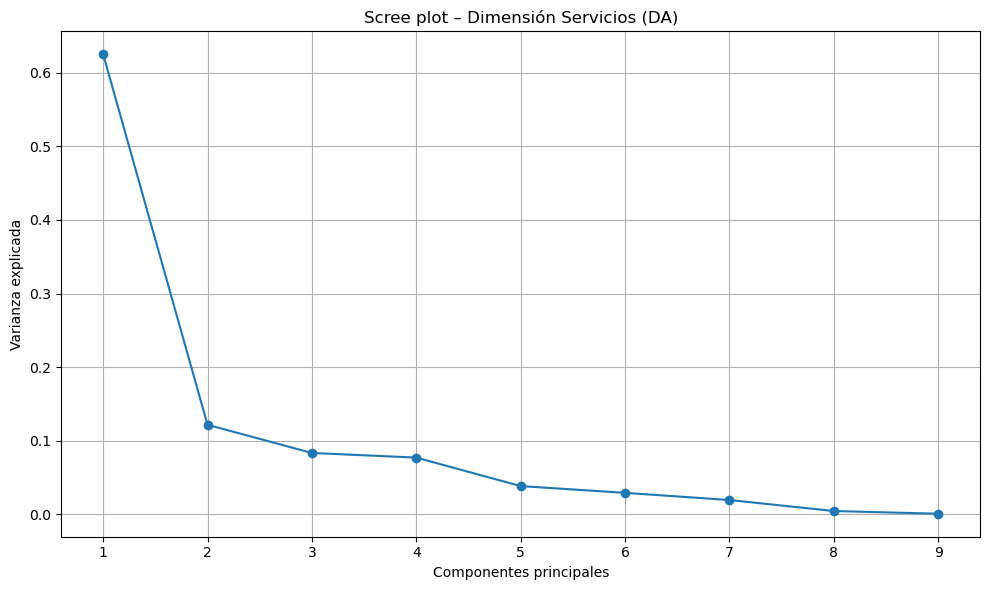

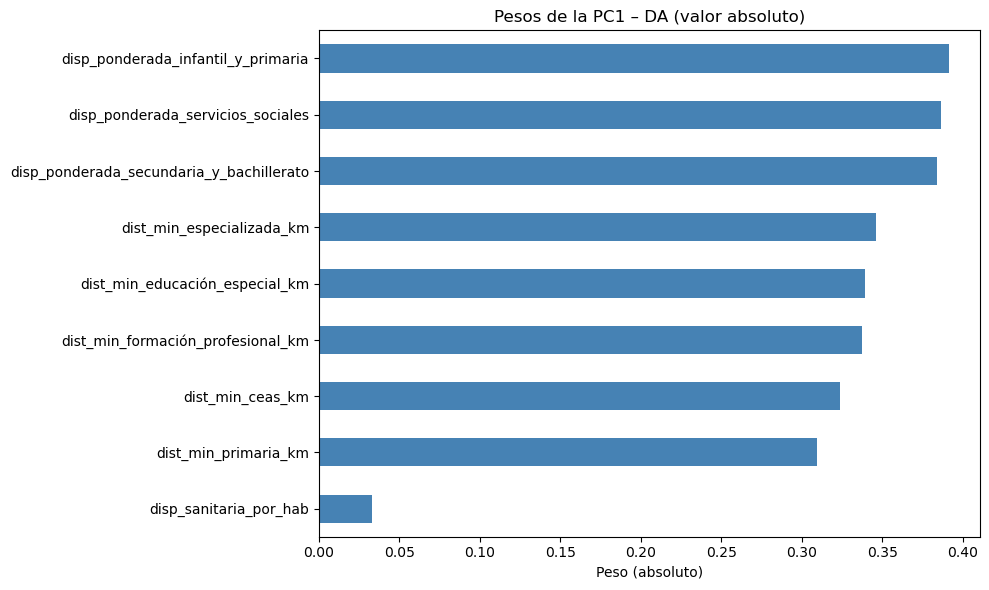

In [12]:
# Variables donde MÁS = mejor (invertir)
vars_invertir_da = [
    "disp_sanitaria_por_hab",
    "disp_ponderada_servicios_sociales",
    "disp_ponderada_secundaria_y_bachillerato",
    "disp_ponderada_infantil_y_primaria",
]

DA_armon = invertir_variables(DA, vars_invertir_da)

# PCA dimensión DA
pca_da, DA_PCA, var_exp_da, loadings_da = pca_dimension(
    DA_armon, vars_da, "DA"
)

print(f"PCA de la dimensión servicios (DA):\n\n{var_exp_da}\n\nMatriz de pesos:\n{loadings_da}\n\n")
plot_scree(pca_da, "Scree plot – Dimensión Servicios (DA)")
plot_loadings_positive(loadings_da, "PC1", "Pesos de la PC1 – DA")

La primera componente principal explica un 56 % de la varianza total, lo que indica una estructura unidimensional clara. Los mayores pesos se concentran en el acceso a servicios educativos (infantil, primaria, secundaria, FP y educación especial), seguidos de los servicios sociales y la sanidad especializada. Asimismo, el transporte público (distancia a paradas y número de líneas) contribuye de forma significativa. Esta estructura refleja un eje de accesibilidad multiservicio que combina educación, servicios sociales, salud y movilidad, coherente con los patrones territoriales de Castilla y León. La variable de dotación sanitaria per cápita presenta un peso reducido, tal y como es esperable por su naturaleza no espacial.

# APLICACIÓN DE PCA A DIMENSIÓN HABITACIONAL (DH)

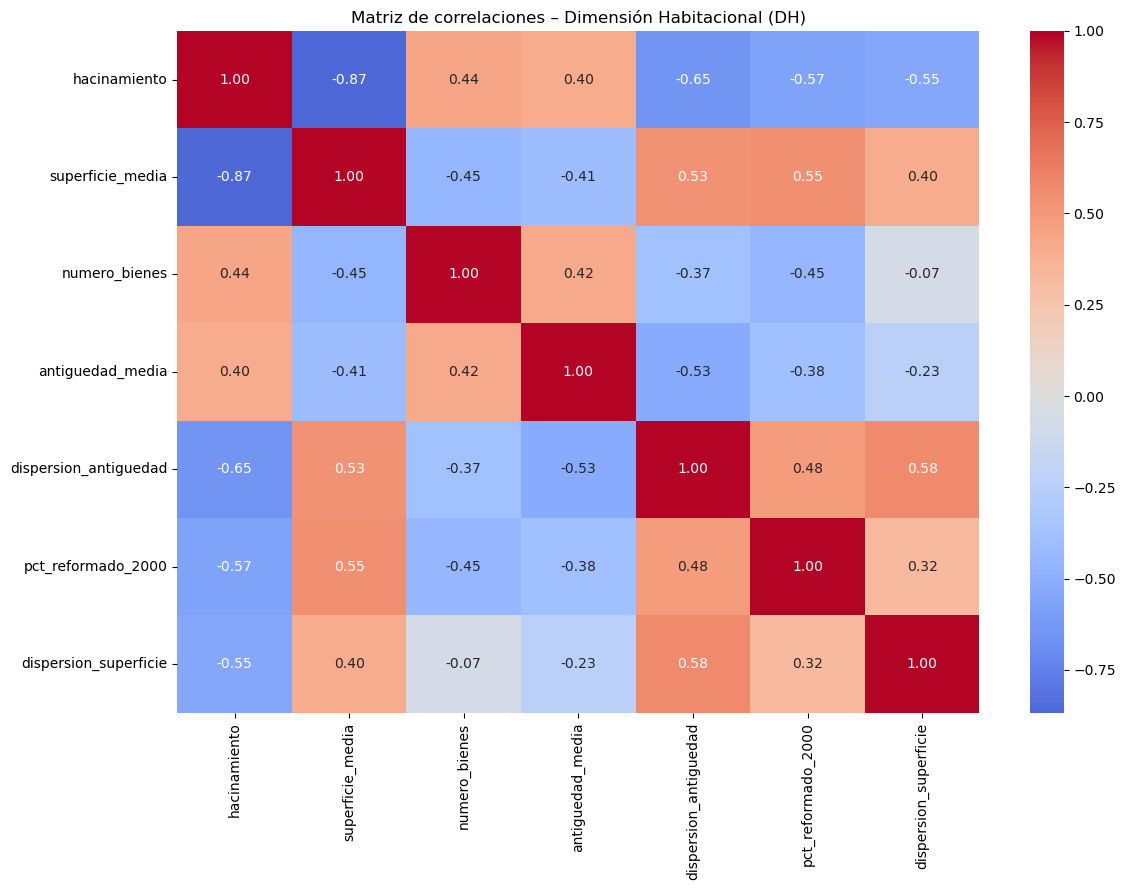

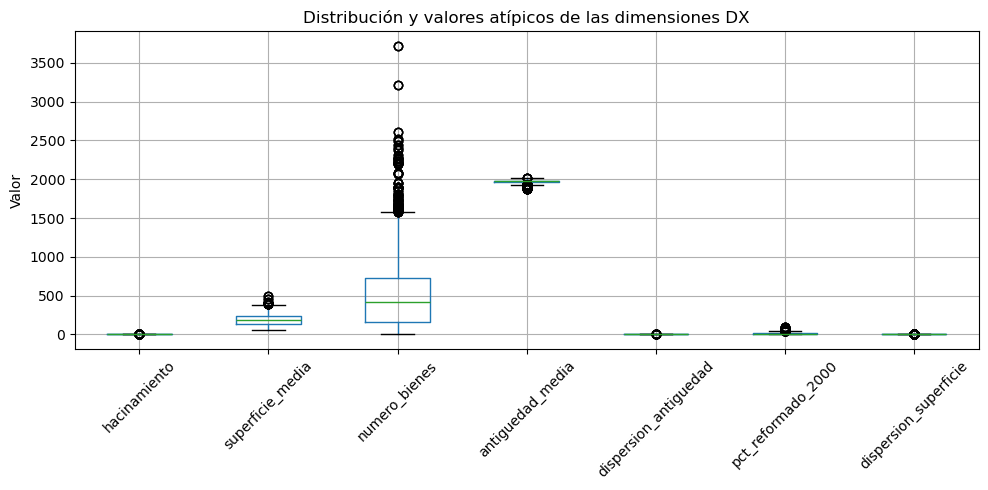

In [35]:
vars_dh = [
    "hacinamiento",
    "superficie_media",
    "numero_bienes",
    "antiguedad_media",
    "dispersion_antiguedad",
    "pct_reformado_2000",
    "dispersion_superficie"
]

DH = DH_seccion[["CUSEC", "Periodo"] + vars_dh].copy()

corr_dh = plot_corr(
    DH,
    vars_dh,
    "Matriz de correlaciones – Dimensión Habitacional (DH)"
)


PCA de la dimensión servicios (DA):

[0.54881024 0.14779832 0.10422826 0.07266957 0.06625273 0.04504119
 0.01519969]

Matriz de pesos:
                            PC1       PC2       PC3       PC4       PC5       PC6       PC7
hacinamiento           0.455172 -0.148272  0.309827 -0.295019  0.103779 -0.054952  0.757638
superficie_media       0.430040  0.001333  0.397475 -0.409542  0.319602  0.042991 -0.620773
numero_bienes         -0.309360 -0.613708 -0.089501  0.075485  0.696399 -0.168513  0.024134
antiguedad_media      -0.324550 -0.309479  0.725099  0.130822 -0.405926 -0.292131 -0.076749
dispersion_antiguedad -0.413424  0.191546  0.355144 -0.056564  0.218473  0.770990  0.144599
pct_reformado_2000     0.374316  0.164479  0.245948  0.838718  0.260228  0.034324  0.000166
dispersion_superficie -0.309542  0.664722  0.160074 -0.125618  0.349126 -0.534595  0.115082




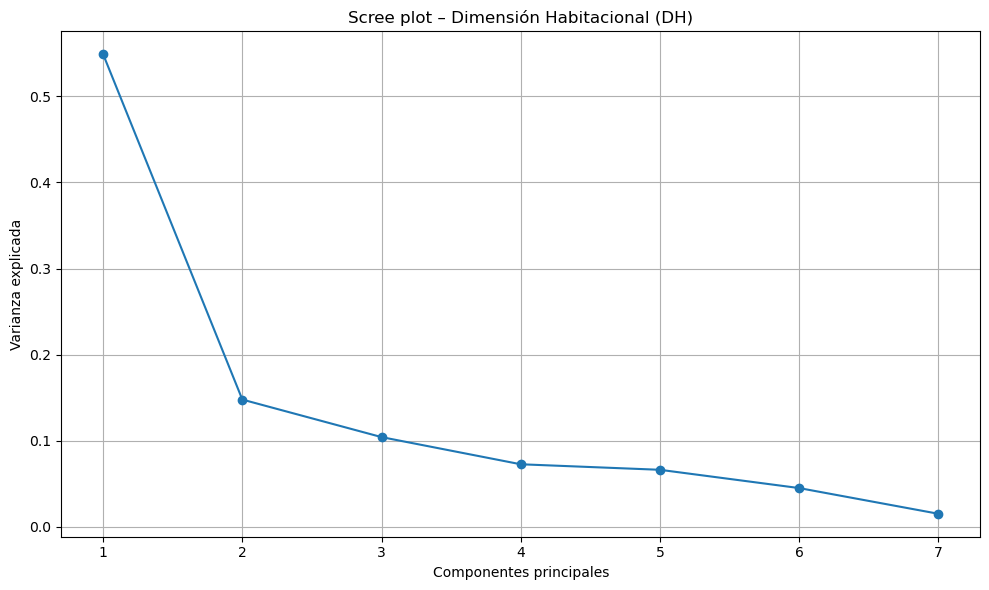

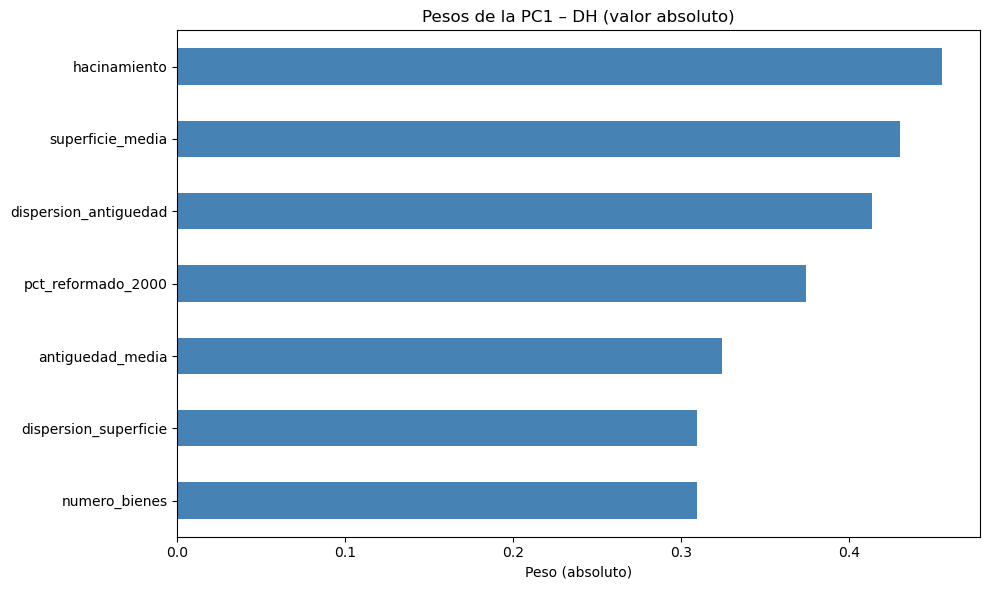

In [14]:
vars_invertir_dh = ["superficie_media", "numero_bienes", "pct_reformado_2000", "antiguedad_media" ]

DH_armon = invertir_variables(DH, vars_invertir_dh)

pca_dh, DH_PCA, var_exp_dh, loadings_dh = pca_dimension(
    DH_armon, vars_dh, "DH"
)

print(f"PCA de la dimensión servicios (DA):\n\n{var_exp_dh}\n\nMatriz de pesos:\n{loadings_dh}\n\n")
plot_scree(pca_dh, "Scree plot – Dimensión Habitacional (DH)")
plot_loadings_positive(loadings_dh, "PC1", "Pesos de la PC1 – DH")

La primera componente principal de la dimensión habitacional explica el 54 % de la varianza total, lo que indica una estructura unidimensional robusta. Los mayores pesos corresponden al hacinamiento, el tamaño reducido de la vivienda, la antigüedad y ausencia de reformas, y la heterogeneidad del parque. Este conjunto de variables configura un eje claro de precariedad residencial, plenamente consistente con los marcos teóricos y empíricos utilizados en estudios de vulnerabilidad territorial.

# APLICACIÓN DE PCA A DIMENSIÓN SOCIOECONÓMICA (DS)

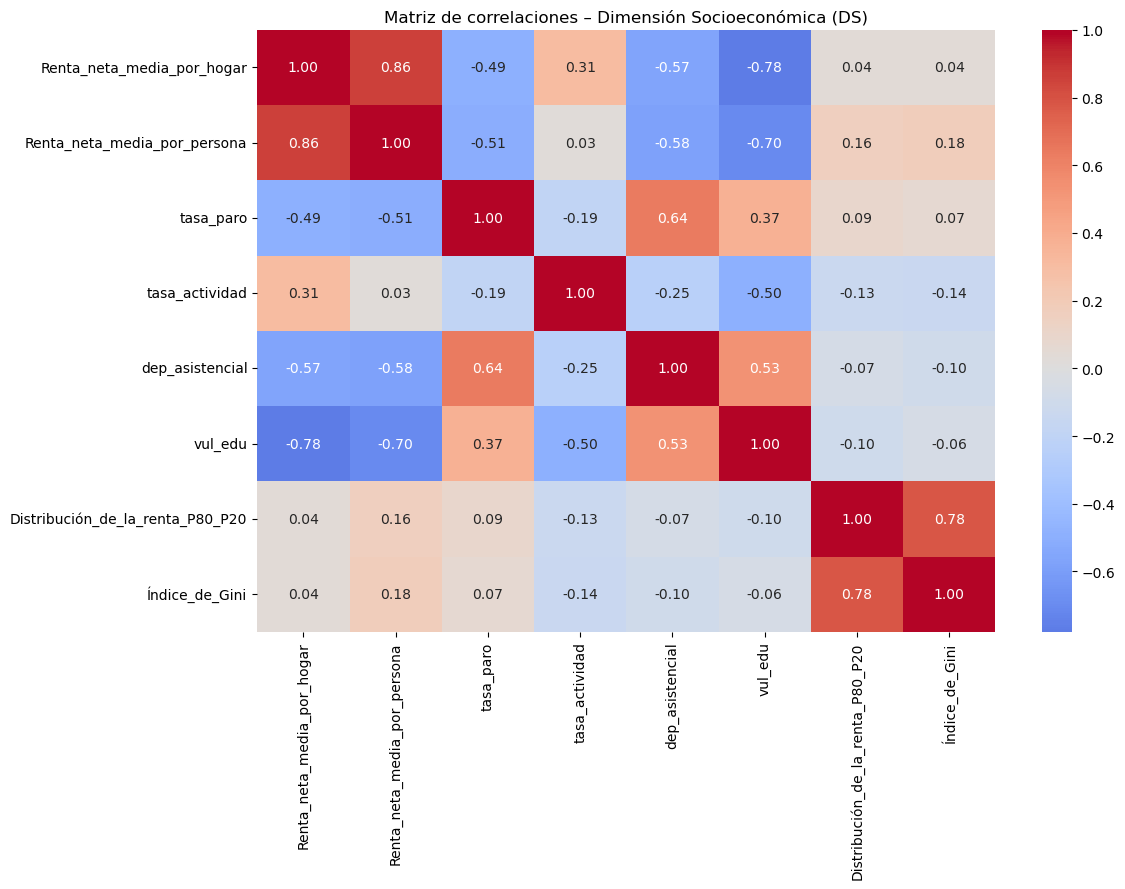

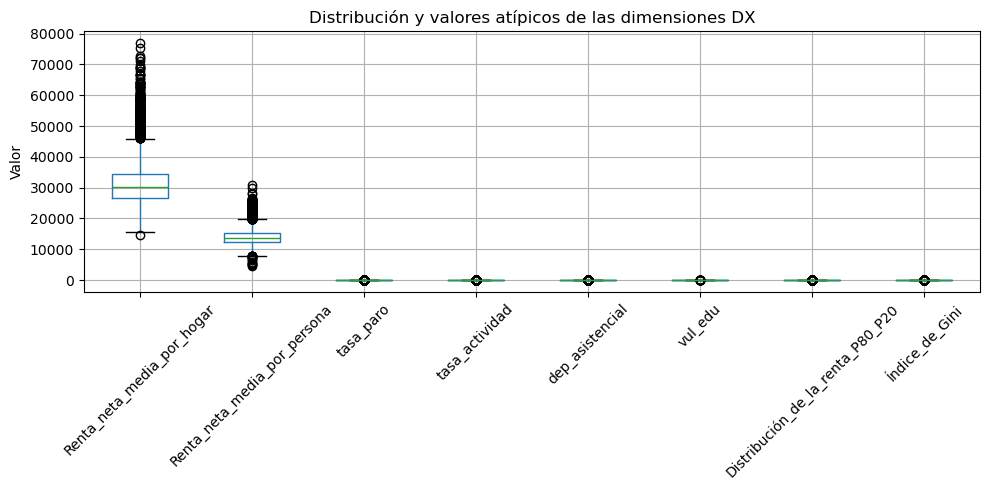

In [36]:
vars_ds = [
    "Renta_neta_media_por_hogar",
    "Renta_neta_media_por_persona",
    "tasa_paro",
    "tasa_actividad",
    "dep_asistencial",
    "vul_edu",
    "Distribución_de_la_renta_P80_P20",
    "Índice_de_Gini"
]

DS = DS_seccion[["CUSEC", "Periodo"] + vars_ds].copy()

corr_ds = plot_corr(
    DS,
    vars_ds,
    "Matriz de correlaciones – Dimensión Socioeconómica (DS)"
)

PCA de la dimensión socioeconómica (DS):

[0.44675502 0.23442053 0.12427153 0.09216681 0.04209161 0.02829749
 0.02127977 0.01071724]

Matriz de pesos:
                                       PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8
Renta_neta_media_por_hogar        0.477731  0.025490 -0.005551 -0.361426 -0.122184 -0.185909 -0.524237 -0.562271
Renta_neta_media_por_persona      0.459203 -0.112798 -0.258375 -0.375803 -0.070500 -0.108680 -0.063879  0.739974
tasa_paro                         0.363024  0.138885 -0.369826  0.555509 -0.603815  0.091455  0.154610 -0.081869
tasa_actividad                    0.210601  0.265706  0.785504  0.304354 -0.134274 -0.151693 -0.232319  0.283526
dep_asistencial                   0.416263  0.007534 -0.177355  0.455337  0.760959  0.011476 -0.090715 -0.021496
vul_edu                           0.451742  0.025779  0.324071 -0.281481  0.069030  0.298535  0.691871 -0.196054
Distribución_de_la_renta_P80_P20 -0.060020  0.668529 -0.16

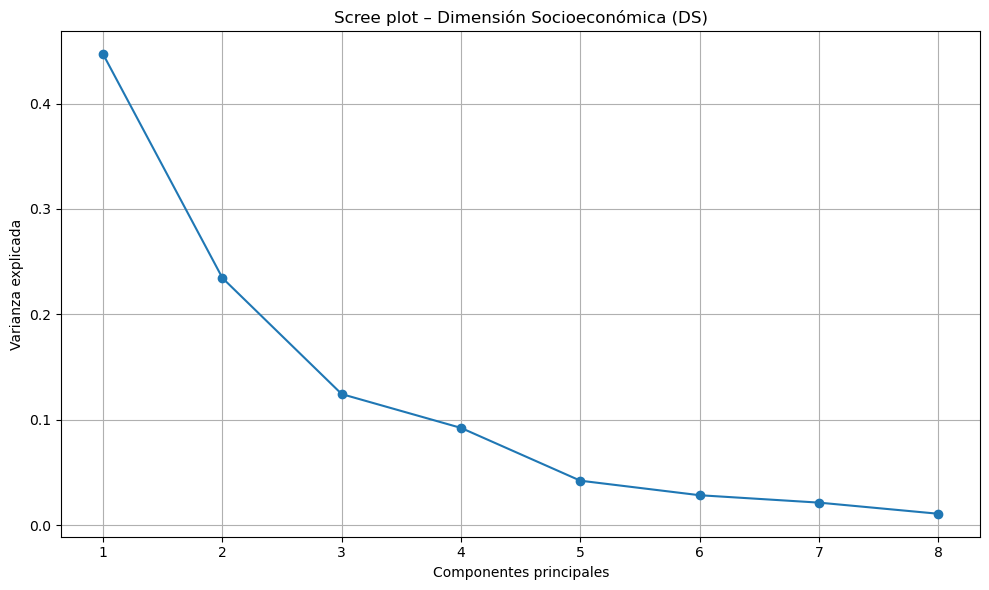

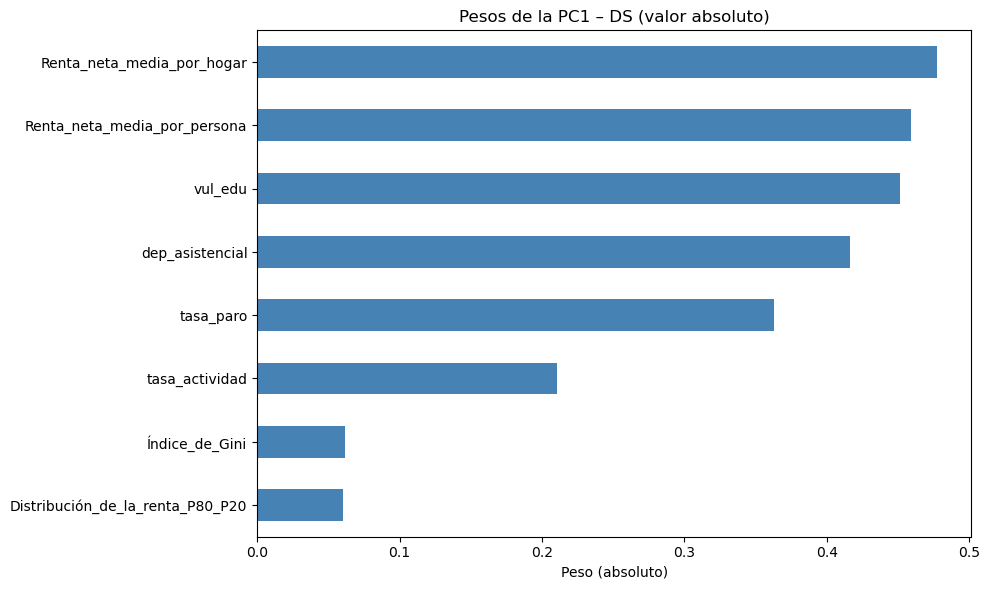

In [16]:
vars_invertir_ds = [
    "Renta_neta_media_por_hogar",
    "Renta_neta_media_por_persona",
    "tasa_actividad"
]

DS_armon = invertir_variables(DS, vars_invertir_ds)

pca_ds, DS_PCA, var_exp_ds, loadings_ds = pca_dimension(
    DS_armon, vars_ds, "DS"
)

print(f"PCA de la dimensión socioeconómica (DS):\n\n{var_exp_ds}\n\nMatriz de pesos:\n{loadings_ds}\n\n")
plot_scree(pca_ds, "Scree plot – Dimensión Socioeconómica (DS)")
plot_loadings_positive(loadings_ds, "PC1", "Pesos de la PC1 – DS")

La primera componente principal explica un 46 % de la varianza total, lo que indica la existencia de un eje socioeconómico bien definido en el territorio. Esta componente está fuertemente determinada por los niveles de renta media por hogar y por persona, que actúan como los principales discriminadores entre secciones censales. A continuación destacan el nivel educativo (en su versión invertida), la dependencia asistencial y la tasa de paro, que conjuntamente reflejan situaciones de menor cualificación, mayor precariedad laboral y mayor exposición a ingresos inestables. La tasa de actividad también contribuye a este eje, aunque con un peso más moderado, capturando diferencias en el dinamismo económico local. Por su parte, las medidas de desigualdad interna (Índice de Gini y ratio P80/P20) presentan una contribución comparativamente menor, coherente con su naturaleza más estructural y menos vinculada a la vulnerabilidad económica directa. En conjunto, esta estructura define un gradiente robusto de vulnerabilidad socioeconómica multicausal, plenamente consistente con la realidad territorial de Castilla y León.

# APLICACIÓN DE PCA A DIMENSIÓN DEMOGRÁFICA (DD)

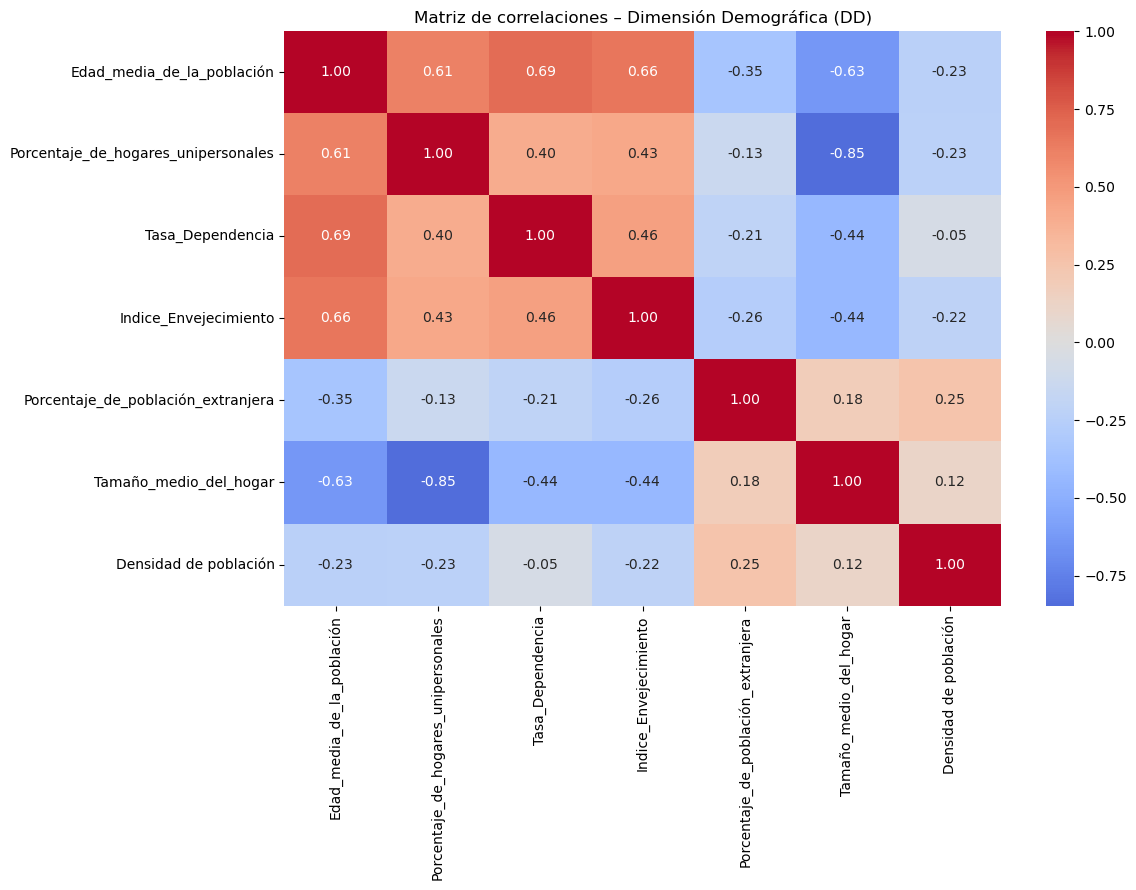

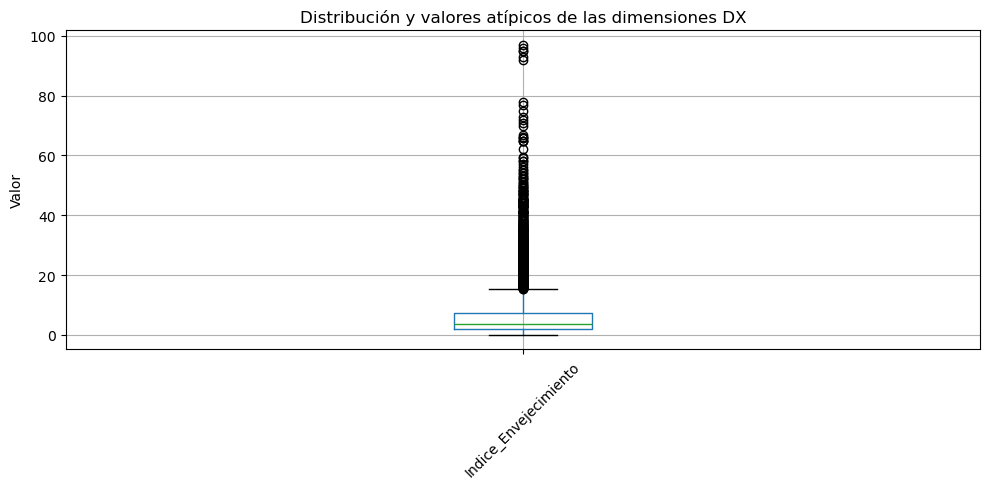

In [38]:
vars_dd = [
    "Edad_media_de_la_población",
    "Porcentaje_de_hogares_unipersonales",
    "Tasa_Dependencia",
    "Indice_Envejecimiento",
    "Porcentaje_de_población_extranjera",
    "Tamaño_medio_del_hogar",
    "Densidad de población"
]

DD = DD_seccion[["CUSEC", "Periodo"] + vars_dd].copy()

corr_dd = plot_corr(
    DD,
    vars_dd,
    "Matriz de correlaciones – Dimensión Demográfica (DD)"
)

PCA de la dimensión demográfica (DD):

[0.49820881 0.16059614 0.12815872 0.09613092 0.06912497 0.02749326
 0.02028718]

Matriz de pesos:
                                          PC1       PC2       PC3       PC4       PC5       PC6       PC7
Edad_media_de_la_población           0.484905 -0.002295 -0.184111 -0.135657 -0.015927  0.843713 -0.021376
Porcentaje_de_hogares_unipersonales  0.429471 -0.258832  0.445042  0.215541 -0.006627 -0.133553 -0.697251
Tasa_Dependencia                     0.382189 -0.139556 -0.468075 -0.303528 -0.612941 -0.383212 -0.026151
Indice_Envejecimiento                0.406876  0.119691 -0.214300 -0.328870  0.751120 -0.318432  0.021590
Porcentaje_de_población_extranjera   0.221125  0.621818 -0.307910  0.675092 -0.045953 -0.086566 -0.065452
Tamaño_medio_del_hogar               0.434909 -0.307981  0.308542  0.334487 -0.019844 -0.112214  0.704228
Densidad de población                0.175395  0.646289  0.559478 -0.408930 -0.239414 -0.044452  0.109601




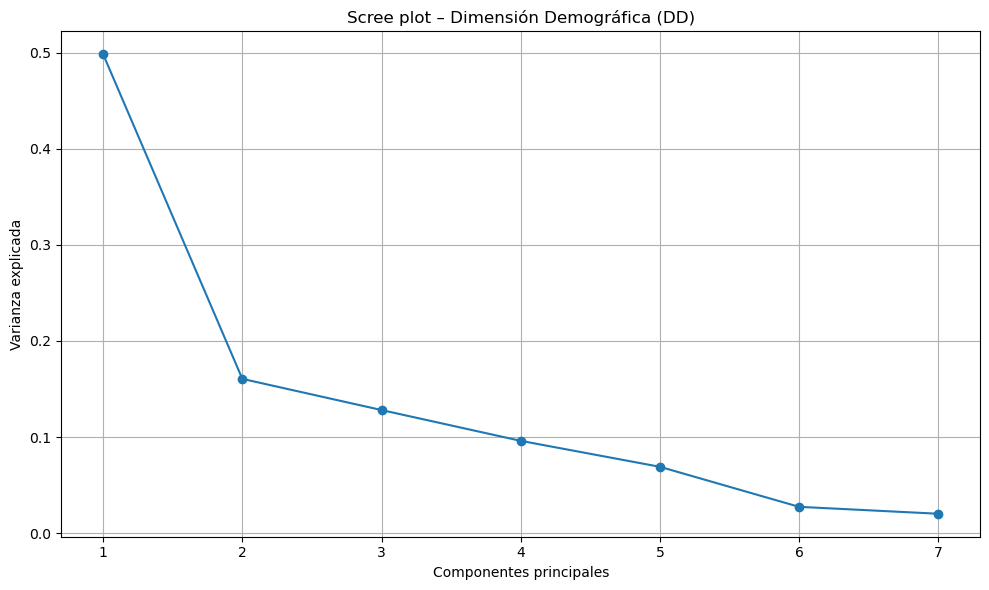

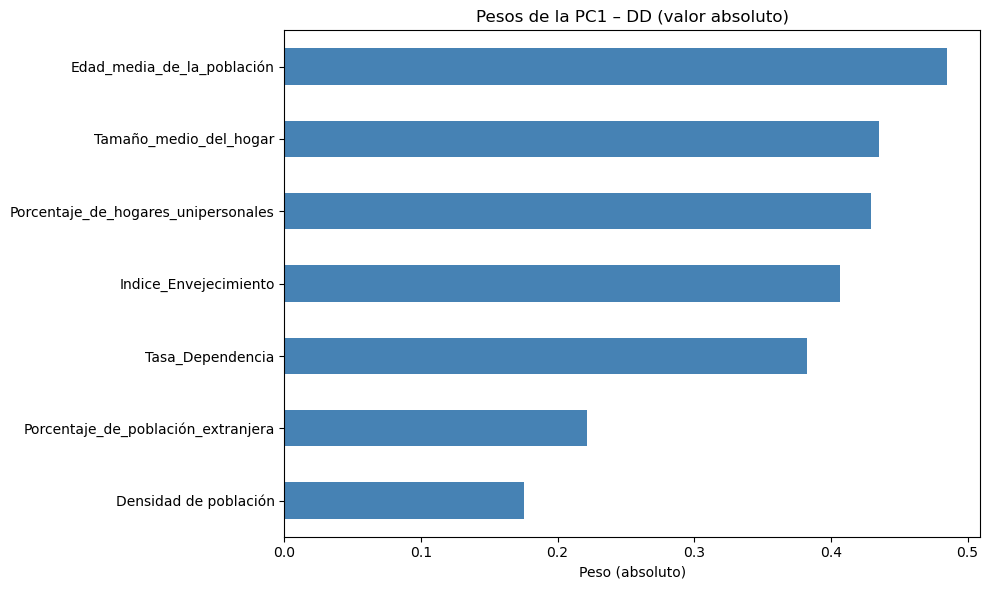

In [18]:
vars_invertir_dd = [
    "Tamaño_medio_del_hogar",   # hogares pequeños = mayor vulnerabilidad
    "Densidad de población" ,    # baja densidad = ruralidad = mayor vulnerabilidad
    "Porcentaje_de_población_extranjera" #menos = menos dinamismo = mayor vulnerabilidad
]
DD_armon = invertir_variables(DD, vars_invertir_dd)

pca_dd, DD_PCA, var_exp_dd, loadings_dd = pca_dimension(
    DD_armon, vars_dd, "DD"
)

print(f"PCA de la dimensión demográfica (DD):\n\n{var_exp_dd}\n\nMatriz de pesos:\n{loadings_dd}\n\n")
plot_scree(pca_dd, "Scree plot – Dimensión Demográfica (DD)")
plot_loadings_positive(loadings_dd, "PC1", "Pesos de la PC1 – DD")

La primera componente principal explica cerca del 50 % de la varianza total, lo que revela un eje demográfico muy definido. Los mayores pesos se concentran en la edad media, el tamaño medio del hogar (invertido), los hogares unipersonales y los indicadores de envejecimiento y dependencia. Este patrón refleja un gradiente demográfico característico de Castilla y León, donde el envejecimiento avanzado, la soledad residencial y la elevada carga de dependencia constituyen los factores diferenciadores fundamentales entre secciones censales. La proporción de población extranjera y la densidad de población aportan una diferenciación secundaria relacionada con el dinamismo urbano-rural, sin modificar la estructura central de la vulnerabilidad demográfica. En conjunto, la PC1 sintetiza adecuadamente la fragilidad demográfica estructural del territorio.

# Construcción del IVST
Una vez obtenida cada comonente de la dimensión, voy a construír un IVST que será también un PCA

In [19]:
# ==========================
# UNIFICACIÓN
# ==========================
IVST = (
    DA_PCA
    .merge(DH_PCA, on=["CUSEC", "Periodo"], how="outer")
    .merge(DS_PCA, on=["CUSEC", "Periodo"], how="outer")
    .merge(DD_PCA, on=["CUSEC", "Periodo"], how="outer")
)

# Imputación mínima, defendible
IVST["DS"] = IVST["DS"].fillna(IVST["DS"].median())
IVST["DD"] = IVST["DD"].fillna(IVST["DD"].median())

IVST.head()

,CUSEC,Periodo,DA,DH,DS,DD
0,0500101001,2021,57.667644,30.889113,42.084450,46.116345
1,0500101001,2022,57.656297,31.199870,38.800487,42.812053
2,0500101001,2023,57.658932,31.199870,35.693302,41.368597
3,0500201001,2021,56.865426,65.463040,48.357214,40.954173
4,0500201001,2022,56.865694,65.463040,46.757071,40.975023


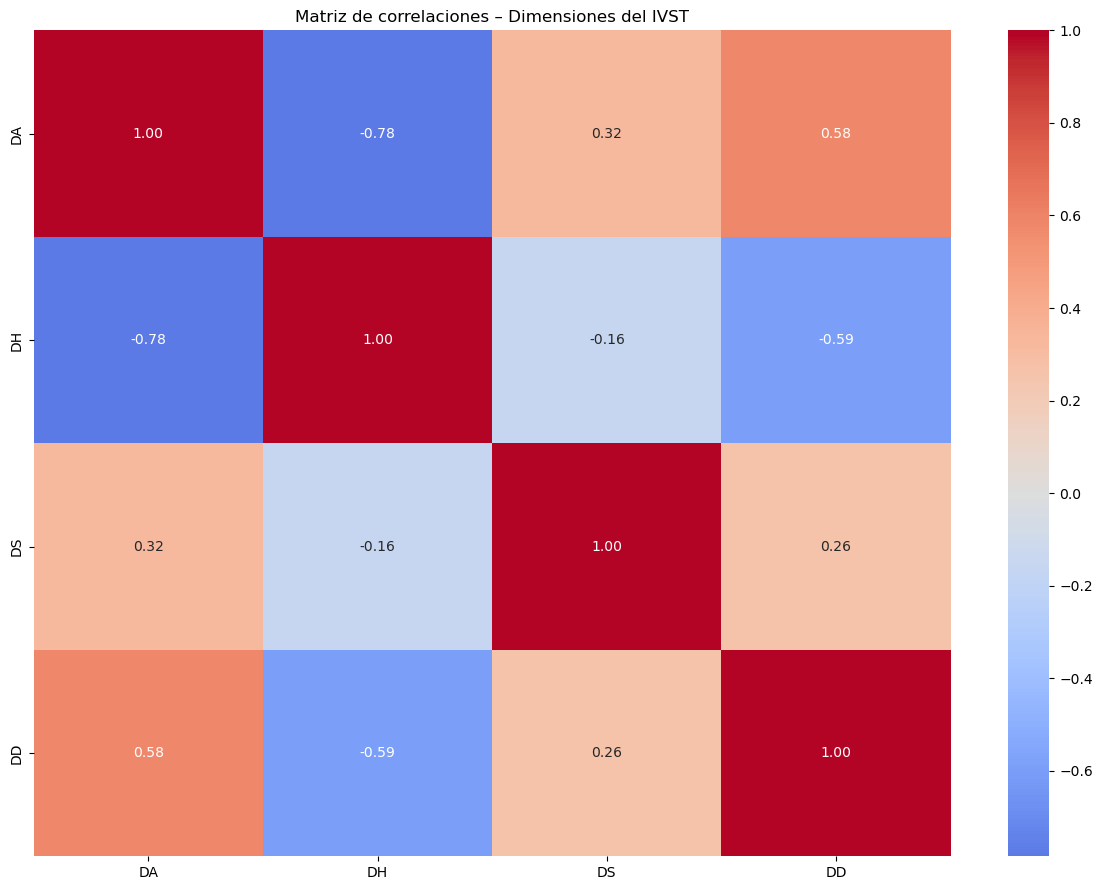

In [20]:
vars_dims = ["DA", "DH", "DS", "DD"]

corr_dims = plot_corr(
    IVST,
    vars_dims,
    "Matriz de correlaciones – Dimensiones del IVST"
)

Las correlaciones elevadas entre DA, DH y DD reflejan la estructura territorial propia de Castilla y León, donde el envejecimiento demográfico, la baja densidad y la dispersión poblacional están fuertemente asociados a peores niveles de accesibilidad a servicios y a peor calidad habitacional. Por tanto, estas dimensiones capturan fenómenos diferenciados pero estrechamente relacionados en la realidad regional.

In [21]:
# Ponderaciones
w_DS = 0.30
w_DD = 0.30
w_DA = 0.25
w_DH = 0.15

# Cálculo del IVST ponderado
IVST["IVST_pond"] = (
    w_DA * IVST["DA"] +
    w_DH * IVST["DH"] +
    w_DS * IVST["DS"] +
    w_DD * IVST["DD"]
)

# Clasificación en 4 grados
IVST["IVST_pond_grado"] = pd.qcut(
    IVST["IVST_pond"],
    q=4,
    labels=["Bajo", "Medio-bajo", "Medio-alto", "Alto"]
)


In [22]:
IVST.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CUSEC            10608 non-null  object  
 1   Periodo          10608 non-null  int64   
 2   DA               10605 non-null  float64 
 3   DH               10605 non-null  float64 
 4   DS               10608 non-null  float64 
 5   DD               10608 non-null  float64 
 6   IVST_pond        10605 non-null  float64 
 7   IVST_pond_grado  10605 non-null  category
dtypes: category(1), float64(5), int64(1), object(1)
memory usage: 590.8+ KB


In [23]:
# Cargo el shp para obtener el id:
ruta_shp_secciones = os.path.join(DATA_OUTPUTS_DIR, "Shapefiles", "cyl_2022.shp")
gdf_secciones = gpd.read_file(ruta_shp_secciones)

# Obtengo el id_seccion
IVST = (
    IVST
    .merge(
        gdf_secciones.drop(columns=["geometry","NMUN","NPRO"]),
        on="CUSEC",
        how="inner"
    )
)

DS_seccion["Seccion_id"] = DS_seccion["Seccion_id"].astype("Int64")
IVST.sample(10)

,CUSEC,Periodo,DA,DH,DS,DD,IVST_pond,IVST_pond_grado,Seccion_id
8737,4718601006,2022,1.385971,59.118002,7.986435,47.058780,25.727757,Bajo,2853
5693,3725901001,2023,54.460036,15.666205,38.337484,55.359870,44.074146,Medio-alto,1842
190,0502201001,2022,51.178540,52.704067,40.655625,39.161919,44.645508,Medio-alto,61
340,0507201001,2022,55.639087,25.540236,38.337484,41.270674,41.623254,Medio-bajo,111
3851,2418801003,2023,51.595397,58.600083,36.555919,34.830663,43.104836,Medio-bajo,1237
3155,2408904006,2023,18.014508,60.527102,33.054127,43.510149,36.551975,Bajo,1031
9813,4904301001,2021,67.942054,30.498242,45.114791,55.531658,51.754184,Alto,3207
9795,4903701001,2021,69.413229,25.144599,46.044749,52.020733,50.544642,Alto,3201
8354,4708503002,2023,44.280883,59.674862,46.347711,33.789690,44.062670,Medio-alto,2725
8879,4718604025,2023,2.696158,78.668999,53.078623,29.516106,37.252808,Bajo,2900


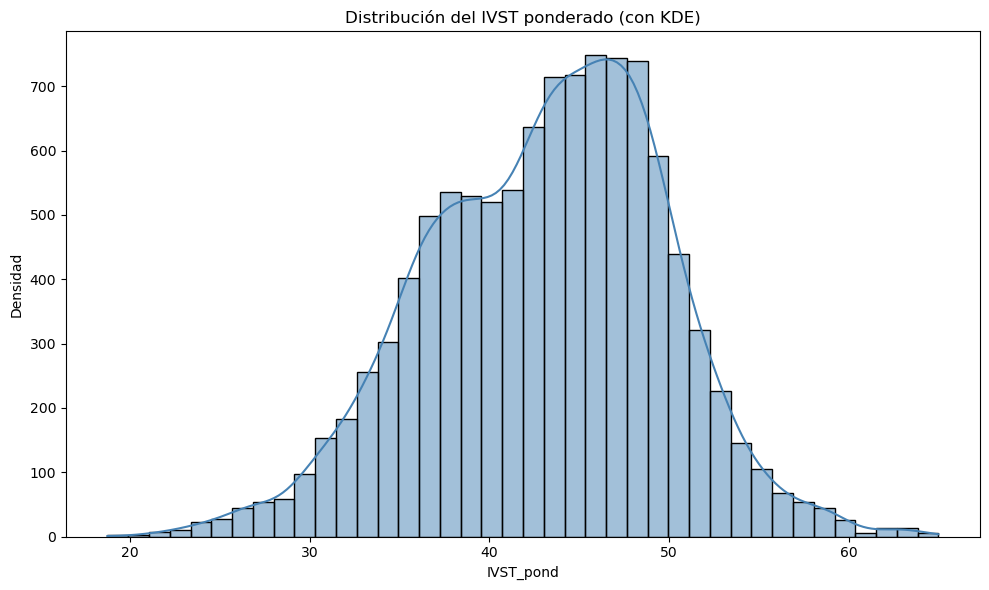

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(IVST["IVST_pond"], bins=40, kde=True, color="steelblue")
plt.title("Distribución del IVST ponderado (con KDE)")
plt.xlabel("IVST_pond")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.cluster import KMeans

X = IVST[["IVST_pond"]].values
kmeans = KMeans(n_clusters=2, random_state=42)
IVST["cluster_k2"] = kmeans.fit_predict(X)

IVST.groupby("cluster_k2")["IVST_pond"].describe()

D:\ANACONDA\envs\ivst\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,count,mean,std,min,25%,50%,75%,max
cluster_k2,,,,,,,,
0,4459.0,36.794338,4.024730,18.750669,34.584826,37.490128,39.929611,42.287786
1,6146.0,47.742212,3.778584,42.290434,44.838942,47.217151,49.832058,64.998604


El análisis de conglomerados confirma que el IVST presenta una estructura claramente bimodal, diferenciando dos patrones territoriales bien definidos: un grupo mayoritario de secciones rurales y semirrurales con niveles elevados de vulnerabilidad estructural, y un grupo minoritario de áreas urbanas y periurbanas con valores significativamente más bajos. Esta dualidad refleja la propia organización socioespacial de Castilla y León y valida la capacidad del índice para capturar desigualdades territoriales de carácter estructural

In [26]:
# Creamos la carpeta si no existe
os.makedirs(DATA_OUTPUTS_DIR, exist_ok=True)

# Rutas de salida
ruta_ivst = os.path.join(DATA_OUTPUTS_DIR, "IVST.csv")

# Guardar DataFrames
IVST.to_csv(
    ruta_ivst,
    index=False,
    encoding="utf-8-sig",
    sep=";",          # separador de columnas compatible con Excel español
    decimal=",",      # separador decimal europeo
    float_format="%.3f"
)

print(f"✅ Archivos guardados correctamente en: {DATA_OUTPUTS_DIR}")

✅ Archivos guardados correctamente en: D:\MASTER EN CIENCIA DE DATOS\TFM\TrabajoFinal\ivst-tfm\data\outputs


In [27]:
IVST.isna().sum()

CUSEC              0
Periodo            0
DA                 0
DH                 0
DS                 0
DD                 0
IVST_pond          0
IVST_pond_grado    0
Seccion_id         0
cluster_k2         0
dtype: int64